# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [167]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [168]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [169]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [170]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [171]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [172]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [173]:
# inspección de plans con .info()
plans.info()
users.info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   ci

In [174]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [175]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [176]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [177]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
dataset users valores nulos 
    city: 469 y proporción 11,725%, el tratamiento para esta columna se debe investigar para tomar la decisión de imputar o dejar como nulos
    churn_date:  3534 y proporción 88.35%, para esta columna no se trata de un error los datos faltantes me informan que los clientes siguen activos 
En dataset usage valores nulos 
    date: 50 y proporción 0.125% el tratamiento es de imputación o como como valor nulo
duration: 22076 y proporción 55.19% el tratamiento se deben conservar los datos nulos e investigar
length: 17896, la proporción es 44.74% el tratamiento se deben conservar los datos nulos e investigar


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [178]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` corresponde al identificador único de cada usuario. La estadística descriptiva muestra que existen 4.000 registros, lo que coincide con el número total de usuarios del dataset.
- La columna `age`, encontramos un valor mínimo de -999, identificado como un sentinel. Este valor se reemplaza por la mediana de la edad, y asi se evita la distorsion en las estadísticas.

In [179]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` estas columnas identifican de forma única cada evento registrado en el dataset usage ya sea una llamada o un mensaje y el identificador único de usuario, respectivamente . Razón por la cual no representa una característica del usuario, por lo que sus estadísticas descriptivas (media, mediana o desviación estándar) no tienen interpretación analítica. Es importante verificar que no existan valores nulos ni registros duplicados en id, a diferencia de user_id, sí es normal que tenga valores repetidos, porque un mismo usuario puede realizar múltiples llamadas y enviar múltiples mensajes, esto garantiza la integridad de la información.
- La columna duration tiene un total de registros de 17924, refleja solo informacion cuando type=call, es decir solo para llamadas. Las media y mediana permiten conocer la duración típica de las llamadas, al revisar la desviación estándar se observa una considerable variabilidad entre ellas. La diferencia entre el valor máximo y los cuartiles indica la existencia de algunas llamadas considerablemente más largas que el resto, lo que sugiere la presencia de usuarios con un mayor consumo del servicio.
Los valores nulos observados en esta columna no corresponden a errores de calidad de los datos, sino a un comportamiento esperado del negocio, dado que los mensajes de texto no poseen una duración.
La columna length tiene un total de registros de 221014, refleja solo informacion cuando type=text, es decir solo para mensajes.La media y la mediana permiten identificar el tamaño promedio de los mensajes enviados, mientras que la desviación estándar muestra la variabilidad existente entre ellos. La diferencia entre el valor máximo y los cuartiles evidencia que algunos usuarios envían mensajes considerablemente más extensos que el promedio.
Los valores nulos presentes en esta variable corresponden al funcionamiento normal del sistema y no representan datos faltantes que requieran tratamiento.

In [180]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts()

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- La columna `city` ...
- La columna `plan` ...

In [181]:
# explorar columna categórica de usage
usage['type'] 
usage["type"].value_counts()

text    22092
call    17908
Name: type, dtype: int64

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Sentinels encontrados en la columna age Edad -999, en City un valor faltante, el cual estaba registrado mediante "?"
- ¿Qué acción tomarías? Los valores, para la columna age, se reemplaza por la mediana de la edad, evitando la distorsion en las estadísticas.
- Para City, se reemplazara por valor nulo.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [182]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['reg_date']

0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]

In [183]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
usage['date']

0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]

In [184]:
# Revisar los años presentes en `reg_date` de users
users_año = users['reg_date'].dt.year
años_presentes = users_año.dropna().value_counts().astype(int)
años_presentes

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`,se registran los años 2022, 2023, 2024, 2026 para el caso de 2026 me muestra un posible error dado que este año aun no transcurre. Y para este año se tienen 40 registros que deben ser analizados.

In [185]:
# Revisar los años presentes en `date` de usage
usage_año = usage['date'].dt.year
años_presentes_usage = usage_año.dropna().value_counts().astype(int)
años_presentes_usage


2024.0    39950
Name: date, dtype: int64

En `date`los años corresponden al año 2024, valores que corresponden al rango que vamos a analizar. Para esta columna se tienen 50 datos a imputar o realizar tratamiento como nulo.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos). Rta: SI, en la informacion de users`reg_date' tenemos 40 datos con fecha imposible
- ¿Qué harías con ellas? Se debe realizar tratamiento como valor nulo.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [186]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, pd.NA)
age_mediana = users["age"].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [187]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users["city"].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [188]:
# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year < 2026)

# Verificar cambios
users_año = users['reg_date'].dt.year
años_presentes = users_año.dropna().value_counts().astype(int)
años_presentes


2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [189]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [190]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`, se confirma que los nulos de las columnas duration y length dependen de type, son MAR, por esta razon se dejan como nulos.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [194]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id",dropna=False).agg({"is_text":"sum","is_call":"sum","duration":"sum"}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [195]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_text":"cant_mensajes",
                              "is_call":"cant_llamadas",
                              "duration":"cant_minutos_llamada"
                                                          })
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [196]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(usage_agg,users, on=['user_id'], how='inner')
user_profile.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [197]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada','age']
user_profile[columnas_numericas].describe()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,age
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,5.524381,4.478120,23.317054,48.138285
std,1154.898108,2.358416,2.144238,18.168095,17.691541
min,10000.000000,0.000000,0.000000,0.000000,18.000000
25%,10999.500000,4.000000,3.000000,11.120000,33.000000
50%,12000.000000,5.000000,4.000000,19.780000,48.000000
75%,12999.500000,7.000000,6.000000,31.415000,63.000000
max,13999.000000,17.000000,15.000000,155.690000,79.000000


In [198]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

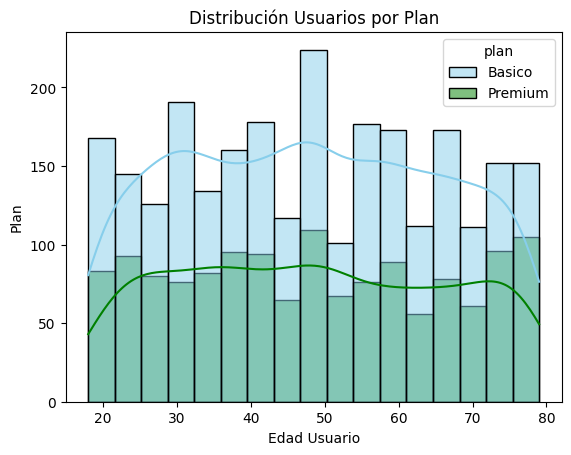

In [199]:
# Histograma para visualizar la edad (age)
sns.histplot(user_profile, x='age', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.xlabel('Edad Usuario')
plt.ylabel('Plan')
plt.title('Distribución Usuarios por Plan')
plt.show()

💡Insights: 
- La distribución de edades es similar entre los usuarios de los planes Básico y Premium. En ambos casos se observa presencia de usuarios en prácticamente todos los rangos de edad (entre 18 y 80 años), sin que exista una concentración marcada en un grupo específico, se observa que el pico de usuarios esta para la edad de 48 a 50 años tanto para plan basico como premium.}
- Se observa que el plan Básico cuenta con un mayor número de usuarios que el plan Premium, ya que sus barras presentan frecuencias más altas en casi todos los rangos de edad. Sin embargo, la forma de ambas distribuciones es similar.
- No se observa un patrón claro que diferencie la distribución de edades entre los usuarios del plan Básico y del plan Premium.

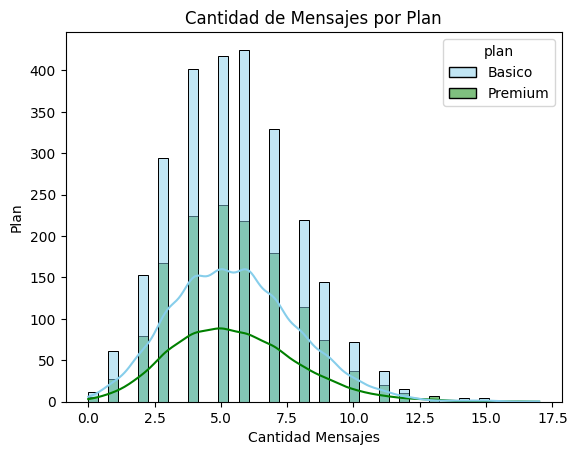

In [200]:
# Histograma para visualizar la cant_mensajes
sns.histplot(user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.xlabel('Cantidad Mensajes')
plt.ylabel('Plan')
plt.title('Cantidad de Mensajes por Plan')
plt.show()

💡Insights: 
- La mayor concentración de usuarios, tanto del plan Básico como del Premium, envío entre 4 y 6 mensajes durante el año 2024. Esto indica que este es el comportamiento más común independientemente del plan contratado.
- Presenta una distribucion sesgada a la derecha, indicando que a medida que aumenta la cantidad de mensajes, el número de usuarios disminuye.
- Los usuarios del plan Básico tienden a enviar una cantidad moderada de mensajes (principalmente entre 4 y 6), mostrando un comportamiento muy similar al de los usuarios Premium. No se observan diferencias importantes en el patrón de envío de mensajes entre ambos planes; la principal diferencia es que el plan Básico tiene una mayor cantidad de usuarios.

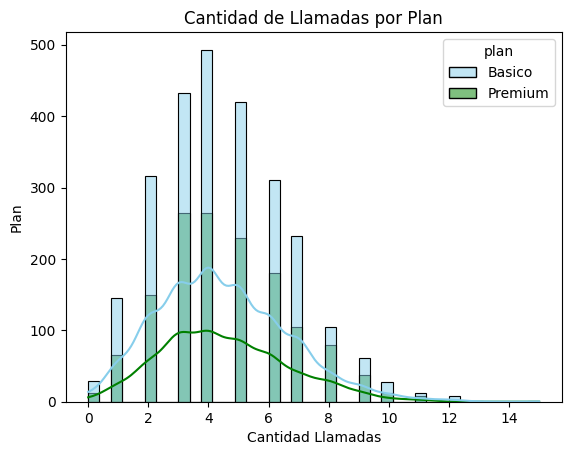

In [201]:
# Histograma para visualizar la cant_llamadas

sns.histplot(user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.xlabel('Cantidad Llamadas')
plt.ylabel('Plan')
plt.title('Cantidad de Llamadas por Plan')
plt.show()


💡Insights: 
- La mayor parte de los usuarios, tanto del plan Básico como del Premium, realiza entre 3 y 5 llamadas, siendo este el intervalo con mayor frecuencia. Esto indica que ambos grupos presentan un comportamiento similar en cuanto al número de llamadas realizadas.
- Presenta una distribución con sesgo a la derecha a medida que aumenta el número de llamadas, disminuye la frecuencia de usuarios, existen pocos usuarios que realizan 10 o más llamadas.

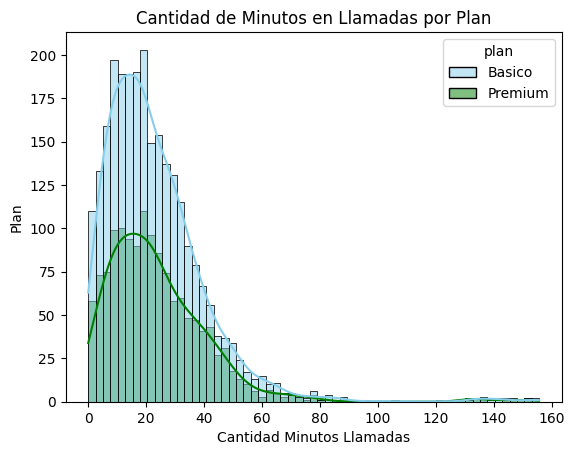

In [202]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True)
plt.xlabel('Cantidad Minutos Llamadas')
plt.ylabel('Plan')
plt.title('Cantidad de Minutos en Llamadas por Plan')
plt.show()


💡Insights: 
- La mayor parte de los usuarios de ambos planes acumula entre 5 y 30 minutos de llamadas durante el período analizado. A medida que aumenta la cantidad de minutos, el número de usuarios disminuye considerablemente.
- El plan Básico presenta una mayor cantidad de usuarios en todos los rangos de minutos, lo que es consistente con el mayor número de clientes registrados en este plan. Sin embargo, la forma de la distribución es muy similar a la del plan Premium, por lo que no se observan diferencias significativas en el patrón de consumo de minutos entre ambos planes.
- Presenta distribucion con sesgo a la derecha existe un pequeño grupo de usuarios que acumula muchos más minutos, la cola de la distribución se extiende hacia los valores altos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

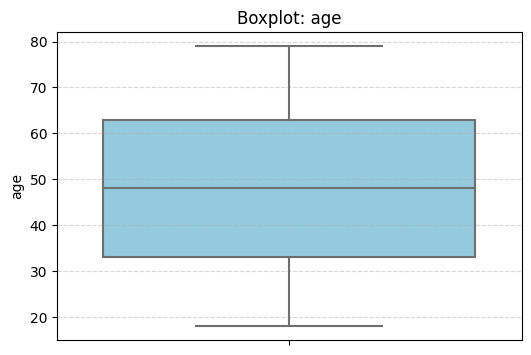

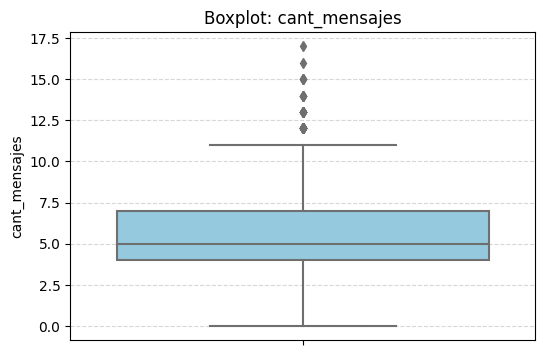

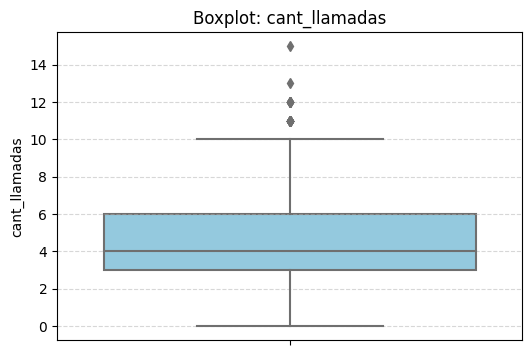

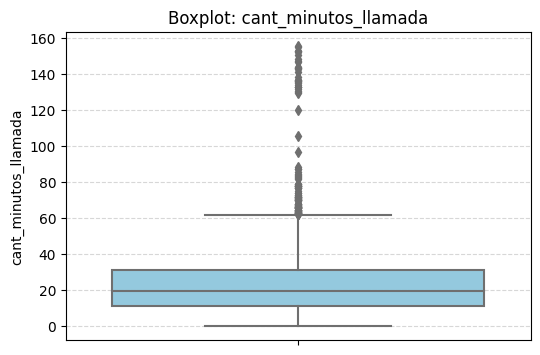

In [203]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()
       


💡Insights: 
- Age: No presenta Outliers
- cant_mensajes: Presenta Outliers en los dos extremos, observando que solo hay un valor en el extremo inferior
- cant_llamadas: Presenta Outliers en los dos extremos, observando que solo hay un valor en el extremo inferior
- cant_minutos_llamada: Presenta mayor cantidad Outliers en extremo superior

In [204]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3-Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f'\n{col}')
    print(f'Q1 = {Q1:.2f}')
    print(f'Q3 = {Q3:.2f}')
    print(f'IQR = {IQR:.2f}')
    print(f'Límite inferior = {limite_inferior:.2f}')
    print(f'Límite superior = {limite_superior:.2f}')


cant_mensajes
Q1 = 4.00
Q3 = 7.00
IQR = 3.00
Límite inferior = -0.50
Límite superior = 11.50

cant_llamadas
Q1 = 3.00
Q3 = 6.00
IQR = 3.00
Límite inferior = -1.50
Límite superior = 10.50

cant_minutos_llamada
Q1 = 11.12
Q3 = 31.41
IQR = 20.30
Límite inferior = -19.32
Límite superior = 61.86


In [205]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?
- Para los outliers identificados en las 3 columnas, dichos valores extremos corresponden a usuarios intensivos y representan comportamiento real del negocio, por lo que no deben eliminarse

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [212]:
# Crear columna grupo_uso
def grupo_uso (row):
    llam = row['cant_llamadas']
    men = row['cant_mensajes']
    if llam < 5 and men < 5:
        return "Bajo uso"
    elif llam < 10 and men < 10:
        return "Uso medio"
    else:
        return "Alto uso"
        
user_profile["grupo_uso"] = user_profile.apply(grupo_uso, axis=1)

In [213]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [214]:
# Crear columna grupo_edad
user_profile["grupo_edad"]  = np.where(
    user_profile['age']<30,'Joven',
    np.where(
        user_profile['age']<60,'Adulto','Adulto Mayor')
)

In [215]:
# verificar cambios
user_profile.head()

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,first_name,last_name,age,city,reg_date,plan,churn_date,grupo_uso,grupo_edad
0,10000,7,3,23.70,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,Uso medio,Adulto
1,10001,5,10,33.18,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,Alto uso,Adulto
2,10002,5,2,10.74,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,Uso medio,Adulto
3,10003,11,3,8.99,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,Alto uso,Adulto Mayor
4,10004,4,3,8.01,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

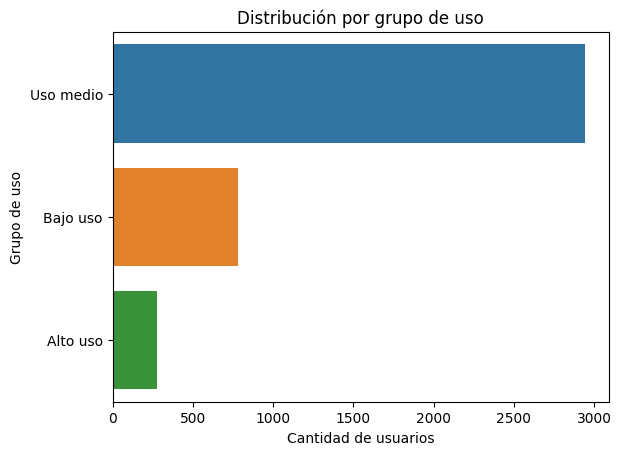

In [216]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, y='grupo_uso', order = user_profile['grupo_uso'].value_counts().index)
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Grupo de uso')
plt.title('Distribución por grupo de uso')
plt.show()


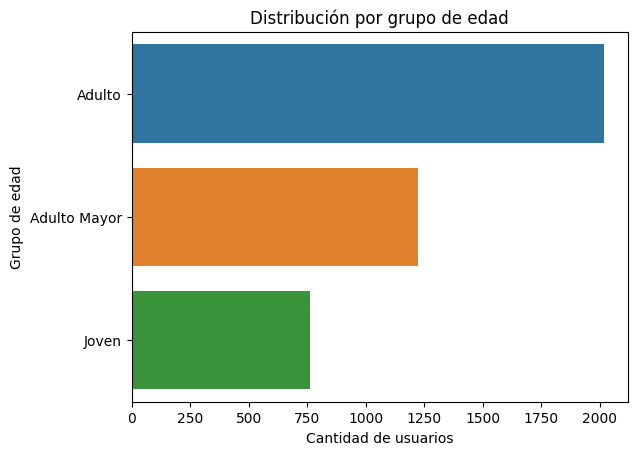

In [217]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, y='grupo_edad', order = user_profile['grupo_edad'].value_counts().index)
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Grupo de edad')
plt.title('Distribución por grupo de edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

En el dataset users la columna city presentó 469 valores nulos (11,73%). Al ser una proporción moderada, estos registros se conservaron para evitar pérdida de información, dejando los valores como nulos después de reemplazar el sentinel "?" por NA.

La columna churn_date presentó 3.534 valores nulos (88,35%). Estos valores no representan un error, sino que indican que los clientes continúan activos, por lo que no fue necesario realizar imputación.

En la columna age se encontró el valor -999, identificado como un sentinel. Este valor fue reemplazado por la mediana de la edad para evitar distorsionar las estadísticas.

En el dataset usage, la columna date presentó 50 valores nulos (0,125%), por lo que su impacto sobre el análisis es mínimo.

Las columnas duration (55,19% de nulos) y length (44,74% de nulos). Sin embargo, se comprobó que estos valores dependen del tipo de registro:

Las llamadas tienen duración pero no longitud del mensaje.
Los mensajes tienen longitud pero no duración.

Por lo tanto, estos valores faltantes corresponden a un patrón MAR (Missing At Random) y no representan errores de calidad.

Finalmente, se identificaron 40 registros con fecha de registro en 2026, un año fuera del periodo analizado (hasta 2024). Estos registros fueron marcados como valores nulos para evitar sesgos en el análisis temporal.



🔍 **Segmentos por Edad**
Los usuarios fueron clasificados en tres grupos:

Jóvenes: menores de 30 años.
Adultos: entre 30 y 59 años.
Adultos mayores: 60 años o más.

La edad promedio de los clientes es cercana a 48 años, con una mediana también de 48 años, lo que indica que la mayoría de los usuarios pertenecen al grupo de adultos.

Los adultos representan el segmento mas grande de la base de clientes, seguido por los adultos mayores, mientras que los usuarios jóvenes constituyen una menor proporción.

Esto indica que ConnectaTel tiene una base de clientes relativamente madura, por lo que las estrategias comerciales deberían enfocarse principalmente en este segmento.


📊 **Segmentos por Nivel de Uso**
Se realizo distribucion a tres segmentos según el comportamiento:

Bajo uso: menos de cinco llamadas y menos de cinco mensajes.
Uso medio: menos de diez llamadas y menos de diez mensajes.
Alto uso: el resto de usuarios.

Los resultados muestran que la mayor parte de los clientes pertenece al grupo de alto uso, seguido por los usuarios de uso medio, mientras que el grupo de bajo uso representa la menor proporción.


➡️ Esto sugiere que que la mayoría de los clientes utiliza activamente los servicios de telefonía y mensajería.


💡 **Recomendaciones**

Crear planes diferenciados para clientes de alto consumo, incluyendo mayores cantidades de minutos y mensajes o beneficios exclusivos que incentiven su permanencia.
Realizar campañas de fidelización para usuarios de alto uso, estos clientes representan el mayor potencial de ingresos.
Implementar estrategias de activación dirigidas a los usuarios de bajo uso, ofreciendo promociones o paquetes adicionales que incentiven un mayor consumo.
Fortalecer los controles de calidad de datos, evitando el registro de edades inválidas, fechas futuras y valores como "?" en la ciudad.
Monitorear continuamente los usuarios con consumo elevado, ya que estos clientes pueden aportar información valiosa para el diseño de nuevos productos o planes Premium.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`